Using category column: product_category_name


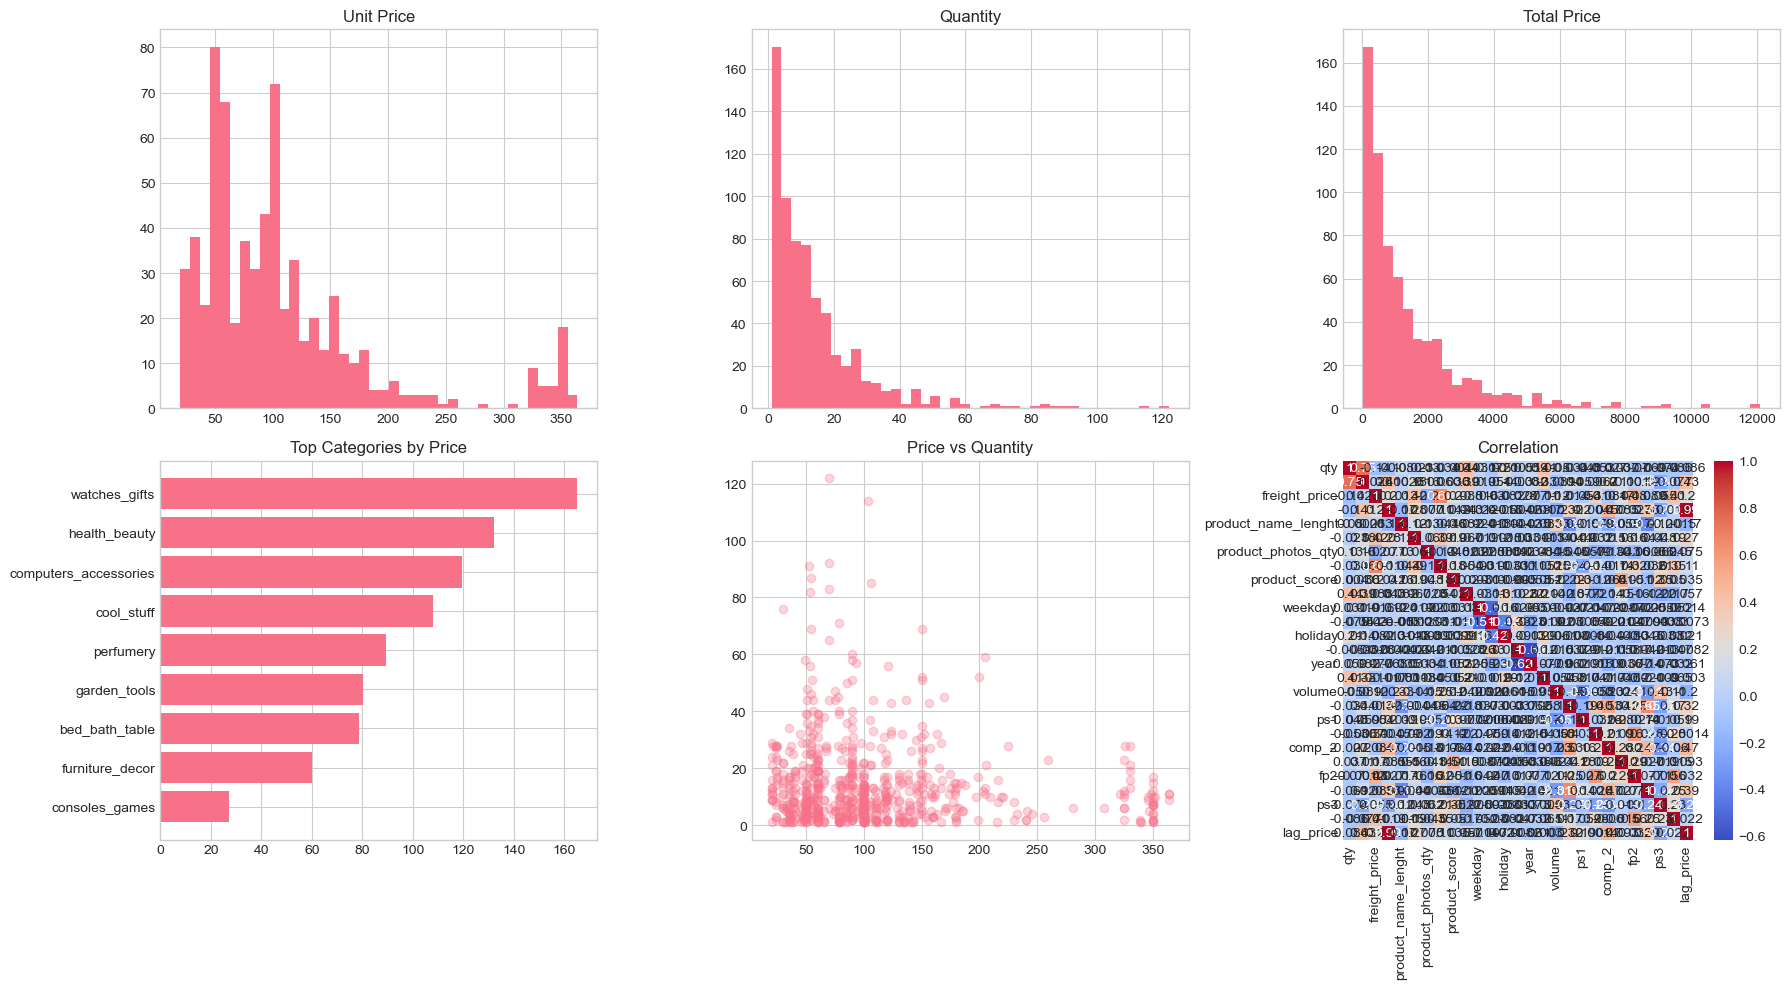

Linear Regression: CV RMSE=14.779, Test RMSE=16.544, R2=-0.010
Random Forest: CV RMSE=13.514, Test RMSE=14.131, R2=0.263
Gradient Boosting: CV RMSE=14.030, Test RMSE=13.649, R2=0.313

Best Model: Gradient Boosting


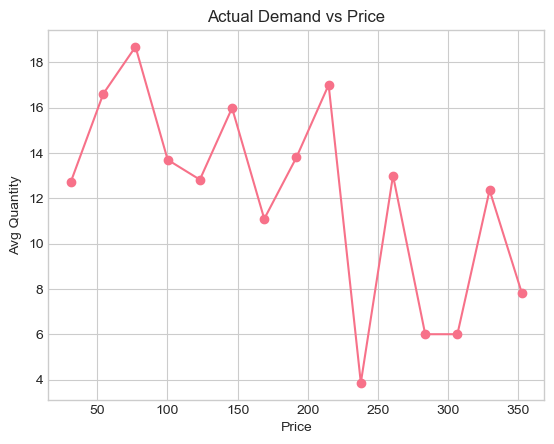

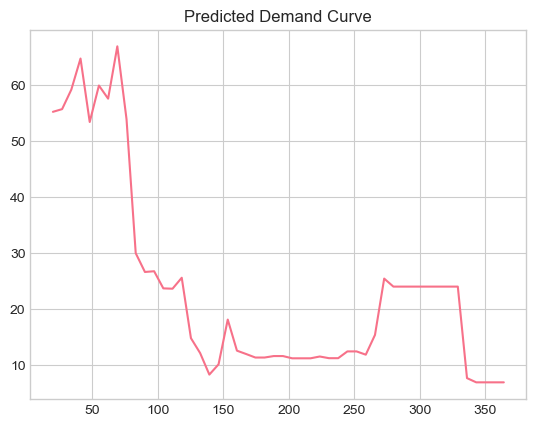

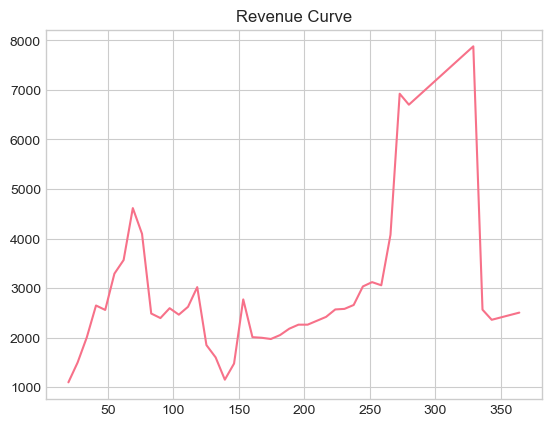


Optimal Price: 328.8877551020408
Max Revenue: 7880.56668672401

Feature Importance:
             Feature  Importance
1  price_to_cat_avg    0.407233
0         log_price    0.342648
3     freight_ratio    0.250119
2      has_discount    0.000000


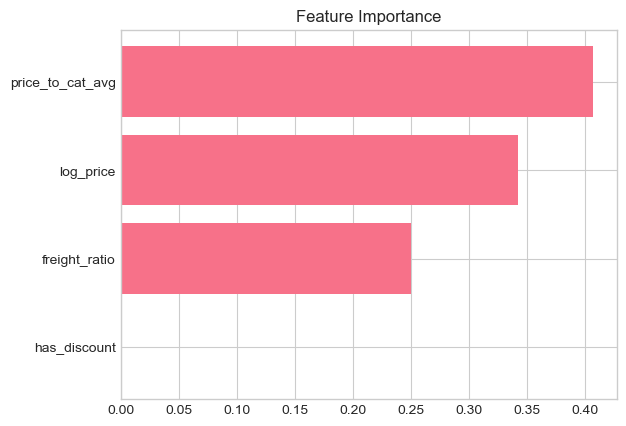

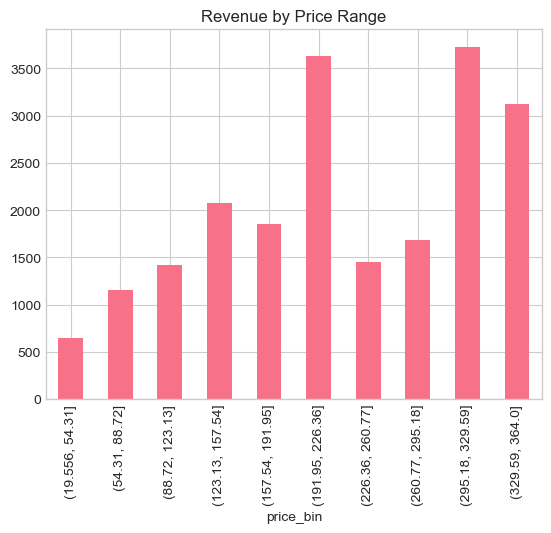

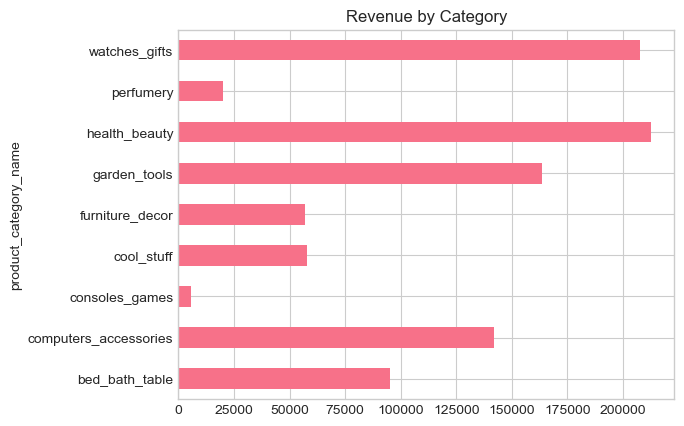


Correlation: -0.10343211686728554
Moderate elasticity → balanced pricing

PROJECT COMPLETE ✅


In [7]:
# ============================================================
# PRICING STRATEGY OPTIMIZATION SYSTEM (COMPLETE VERSION)
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import cross_val_score, KFold, train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

plt.style.use("seaborn-v0_8-whitegrid")

# ==============================
# LOAD DATA
# ==============================
df = pd.read_csv("retail_price.csv")

# Detect category column
CATEGORY_COL = None
for col in df.columns:
    if "category" in col.lower():
        CATEGORY_COL = col
        break

print("Using category column:", CATEGORY_COL)

# ==============================
# EDA (NEW - COMPLETE)
# ==============================
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Distributions
axes[0,0].hist(df["unit_price"], bins=40)
axes[0,0].set_title("Unit Price")

axes[0,1].hist(df["qty"], bins=40)
axes[0,1].set_title("Quantity")

axes[0,2].hist(df["total_price"], bins=40)
axes[0,2].set_title("Total Price")

# Category avg price
if CATEGORY_COL:
    cat_price = df.groupby(CATEGORY_COL)["unit_price"].mean().sort_values(ascending=False).head(10)
    axes[1,0].barh(cat_price.index.astype(str), cat_price.values)
    axes[1,0].invert_yaxis()
    axes[1,0].set_title("Top Categories by Price")

# Scatter
axes[1,1].scatter(df["unit_price"], df["qty"], alpha=0.3)
axes[1,1].set_title("Price vs Quantity")

# Correlation heatmap
corr = df.select_dtypes(include=np.number).corr()
sns.heatmap(corr, ax=axes[1,2], annot=True, cmap="coolwarm")
axes[1,2].set_title("Correlation")

plt.tight_layout()
plt.show()

# ==============================
# CLEANING
# ==============================
df.dropna(subset=["unit_price", "qty", "total_price"], inplace=True)
df = df[(df["unit_price"] > 0) & (df["qty"] > 0)]

# ==============================
# FEATURE ENGINEERING (IMPROVED)
# ==============================
df["revenue"] = df["unit_price"] * df["qty"]
df["log_price"] = np.log1p(df["unit_price"])
df["log_qty"] = np.log1p(df["qty"])

# Category avg price
if CATEGORY_COL:
    cat_avg = df.groupby(CATEGORY_COL)["unit_price"].transform("mean")
else:
    cat_avg = df["unit_price"].mean()

df["price_to_cat_avg"] = df["unit_price"] / (cat_avg + 1e-9)

# Extra features
if "discount" in df.columns:
    df["has_discount"] = (df["discount"] > 0).astype(int)
else:
    df["has_discount"] = 0

if "freight_price" in df.columns:
    df["freight_ratio"] = df["freight_price"] / (df["unit_price"] + 1e-9)
else:
    df["freight_ratio"] = 0

# Price bucket
df["price_bucket"] = pd.qcut(df["unit_price"], q=5, labels=["Low","Mid","High","Premium","Luxury"])

# ==============================
# ENCODING
# ==============================
le = LabelEncoder()
cat_cols = df.select_dtypes(include=["object"]).columns

for col in cat_cols:
    df[col + "_enc"] = le.fit_transform(df[col].astype(str))

# ==============================
# FEATURES
# ==============================
FEATURE_COLS = [
    "log_price",
    "price_to_cat_avg",
    "has_discount",
    "freight_ratio"
]

TARGET = "qty"

X = df[FEATURE_COLS].fillna(0)
y = df[TARGET]

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

# ==============================
# MODELS + CV
# ==============================
kf = KFold(n_splits=5, shuffle=True, random_state=42)

models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100),
    "Gradient Boosting": GradientBoostingRegressor()
}

results = {}

for name, model in models.items():
    cv = cross_val_score(model, X_train_sc, y_train,
                         scoring="neg_mean_squared_error", cv=kf)
    cv_rmse = np.sqrt(-cv).mean()

    model.fit(X_train_sc, y_train)
    pred = model.predict(X_test_sc)

    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)

    results[name] = {"model": model, "rmse": rmse, "cv": cv_rmse, "r2": r2, "pred": pred}

    print(f"{name}: CV RMSE={cv_rmse:.3f}, Test RMSE={rmse:.3f}, R2={r2:.3f}")

# Best model
best_name = min(results, key=lambda x: results[x]["rmse"])
best_model = results[best_name]["model"]

print("\nBest Model:", best_name)

# ==============================
# DEMAND VS PRICE (REAL DATA) ✅
# ==============================
df["price_bin"] = pd.cut(df["unit_price"], bins=15)

demand_curve = df.groupby("price_bin").agg({"qty":"mean"}).reset_index()
demand_curve["mid_price"] = demand_curve["price_bin"].apply(lambda x: x.mid)

plt.plot(demand_curve["mid_price"], demand_curve["qty"], marker="o")
plt.title("Actual Demand vs Price")
plt.xlabel("Price")
plt.ylabel("Avg Quantity")
plt.show()

# ==============================
# DEMAND + REVENUE CURVE (MODEL)
# ==============================
price_range = np.linspace(df["unit_price"].min(), df["unit_price"].max(), 50)

pred_demand = []
for p in price_range:
    row = {
        "log_price": np.log1p(p),
        "price_to_cat_avg": p / df["unit_price"].mean(),
        "has_discount": 0,
        "freight_ratio": 0
    }
    pred = best_model.predict(scaler.transform(pd.DataFrame([row])))
    pred_demand.append(pred[0])

pred_demand = np.maximum(pred_demand, 0)
revenue = price_range * np.array(pred_demand)

plt.plot(price_range, pred_demand)
plt.title("Predicted Demand Curve")
plt.show()

plt.plot(price_range, revenue)
plt.title("Revenue Curve")
plt.show()

# ==============================
# OPTIMAL PRICE
# ==============================
idx = np.argmax(revenue)
print("\nOptimal Price:", price_ranśge[idx])
print("Max Revenue:", revenue[idx])

# ==============================
# FEATURE IMPORTANCE ✅
# ==============================
if hasattr(best_model, "feature_importances_"):
    imp = best_model.feature_importances_

    imp_df = pd.DataFrame({
        "Feature": FEATURE_COLS,
        "Importance": imp
    }).sort_values("Importance", ascending=False)

    print("\nFeature Importance:\n", imp_df)

    plt.barh(imp_df["Feature"], imp_df["Importance"])
    plt.gca().invert_yaxis()
    plt.title("Feature Importance")
    plt.show()

# ==============================
# REVENUE INSIGHTS
# ==============================
df["price_bin"] = pd.cut(df["unit_price"], bins=10)

rev_bin = df.groupby("price_bin")["revenue"].mean()
rev_bin.plot(kind="bar")
plt.title("Revenue by Price Range")
plt.show()

if CATEGORY_COL:
    rev_cat = df.groupby(CATEGORY_COL)["revenue"].sum().head(10)
    rev_cat.plot(kind="barh")
    plt.title("Revenue by Category")
    plt.show()

# ==============================
# STRATEGY
# ==============================
corr = df["unit_price"].corr(df["qty"])
print("\nCorrelation:", corr)

if corr < -0.3:
    print("High elasticity → lower price increases demand")
elif corr < 0:
    print("Moderate elasticity → balanced pricing")
else:
    print("Low elasticity → premium pricing possible")

print("\nPROJECT COMPLETE ✅")

In [ ]:
.